In [1]:
import pandas as pd 
import numpy as np 
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from thefuzz import process, fuzz
import geopandas as gpd

In [2]:
# Importar datos 
df_clientes_regulados = pd.read_csv("../data/raw/se_facturacion_clientes_regulados(in).csv", delimiter=";", encoding="utf-8-sig")
df_clientes_libres = pd.read_csv("../data/raw/se_venta_energia_clientes_libres(in).csv", delimiter=";", decimal=",", thousands=".")

In [3]:
# Función para reparar la doble codificación
def reparar_mojibake(texto):
    if isinstance(texto, str):
        try:
            # Ingeniería inversa: convertimos a bytes crudos cp1252 y decodificamos en utf-8
            return texto.encode('cp1252').decode('utf-8')
        except (UnicodeEncodeError, UnicodeDecodeError):
            # Si falla (ej. si la palabra ya estaba bien escrita), la dejamos intacta
            return texto
    return texto

# 3. Aplicar la función a las columnas de texto (ej. "region")
# Reemplaza 'nombre_region' por el nombre real de tu columna
df_clientes_regulados['region'] = df_clientes_regulados['region'].apply(reparar_mojibake)
df_clientes_regulados['comuna'] = df_clientes_regulados['comuna'].apply(reparar_mojibake)

# Comprobación
print(df_clientes_regulados['region'].unique())
print(df_clientes_regulados['comuna'].unique())

<ArrowStringArray>
['Región del Libertador Gral. Bernardo O’Higgins',
                              'Región del Biobío',
                               'Región del Maule',
                           'Región de Valparaíso',
               'Región Metropolitana de Santiago',
                         'Región de La Araucanía',
                            'Región de Los Lagos',
                              'Región de Atacama',
  'Región Aisén del Gral.Carlos Ibáñez del Campo',
                             'Región de Coquimbo',
                          'Región de Antofagasta',
                   'Región de Arica y Parinacota',
                             'Región de Tarapacá',
                                'Región de Ñuble',
                             'Región de Los Ríos',
 'Región de Magallanes y de la Antártica Chilena']
Length: 16, dtype: str
<ArrowStringArray>
[      'Las Cabras',      'La Estrella',         'Litueche',
          'Doñihue',         'Graneros',         'Coltauco',
 

In [4]:
# Limpieza exhaustiva de la columna RetiroEnergiaMWh
df_clientes_libres['RetiroEnergiaMWh'] = (
    df_clientes_libres['RetiroEnergiaMWh']
    .astype(str)                          # Asegurar que todo sea string
    .str.strip()                          # Eliminar espacios fantasma a los lados
    .str.replace('.', '', regex=False)    # Eliminar separadores de miles si los hay
    .str.replace(',', '.', regex=False)   # Cambiar coma decimal por punto de Python
)

# 3. Forzar a numérico. 
# errors='coerce' transformará cualquier basura ("-", "ND", etc.) en NaN (nulo)
df_clientes_libres['RetiroEnergiaMWh'] = pd.to_numeric(
    df_clientes_libres['RetiroEnergiaMWh'], 
    errors='coerce'
)

# Comprobación de que ahora sí es float
print(df_clientes_libres['RetiroEnergiaMWh'].dtype)

float64


In [5]:
# Identificación de regiones y comunas en cada fuente
regiones_regulados = df_clientes_regulados["region"].unique().tolist()
comunas_regulados = df_clientes_regulados["comuna"].unique().tolist()

regiones_libres = df_clientes_libres["Region"].unique().tolist()
comunas_libres = df_clientes_libres["Comuna"].unique().tolist()

print(10 * "-" + "Regiones" + 10 * "-")
print(f"Base de clientes regulados: {len(regiones_regulados)}")
print(regiones_regulados)
print(f"Base de clientes libres: {len(regiones_libres)}")
print(regiones_libres)

print(10 * "-" + "Comunas" + 10 * "-")
print(f"Base de clientes regulados: {len(comunas_regulados)}")
print(comunas_regulados)
print(f"Base de clientes libres: {len(comunas_libres)}")
print(comunas_libres)

----------Regiones----------
Base de clientes regulados: 16
['Región del Libertador Gral. Bernardo O’Higgins', 'Región del Biobío', 'Región del Maule', 'Región de Valparaíso', 'Región Metropolitana de Santiago', 'Región de La Araucanía', 'Región de Los Lagos', 'Región de Atacama', 'Región Aisén del Gral.Carlos Ibáñez del Campo', 'Región de Coquimbo', 'Región de Antofagasta', 'Región de Arica y Parinacota', 'Región de Tarapacá', 'Región de Ñuble', 'Región de Los Ríos', 'Región de Magallanes y de la Antártica Chilena']
Base de clientes libres: 29
['región del biobío', 'región de atacama', 'región del libertador gral. bernardo o’higgins', 'región de valparaíso', 'región de arica y parinacota', 'región de tarapacá', 'región del maule', 'región metropolitana de santiago', 'región de coquimbo', 'región de antofagasta', 'región de los ríos', 'región de la araucanía', 's/i', 'región de los lagos', 'región de ñuble', 'Región Metropolitana de Santiago', 'Región de La Araucanía', 'Región del Maul

In [7]:
# Diccionario de regiones 
mapa_regiones = {
    "TARAPACÁ": "TA", 
    "ANTOFAGASTA": "AN", 
    "ATACAMA": "AT", 
    "COQUIMBO": "CO", 
    "VALPARAÍSO": "VS", 
    "LIBERTADOR GENERAL BERNARDO O'HIGGINS": "LI", 
    "MAULE": "ML", 
    "BIOBÍO": "BI", 
    "LA ARAUCANÍA": "AR", 
    "LOS LAGOS": "LL", 
    "AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO": "AI", 
    "MAGALLANES Y DE LA ANTÁRTICA CHILENA": "MA", 
    "METROPOLITANA DE SANTIAGO": "RM", 
    "LOS RÍOS": "LR", 
    "ARICA Y PARINACOTA": "AP", 
    "ÑUBLE": "NB",
}

# Función para limpiar los nombres de las regiones
def limpiar_nombres(nombre):
    if pd.isna(nombre) or str(nombre).strip().lower() == 's/i':
        return np.nan
    
    # Mayúsculas y quitar espacios
    x = str(nombre).upper().strip()
    
    # Eliminar prefijos
    x = x.replace("REGIÓN DEL ", "").replace("REGIÓN DE ", "").replace("REGIÓN ", "")
    
    # Corregir abreviaturas y tildes específicas
    x = x.replace("GRAL.CARLOS", "GENERAL CARLOS")
    x = x.replace("GRAL. CARLOS", "GENERAL CARLOS")
    x = x.replace("GRAL. BERNARDO", "GENERAL BERNARDO")
    x = x.replace("O’HIGGINS", "O'HIGGINS") # Apóstrofe curvo a recto
    x = x.replace("AISÉN", "AYSÉN")
    x = x.replace("COIHAIQUE", "COYHAIQUE")
    
    return x

# Función para limpiar las comunas
def limpiar_comunas(nombre):
    if pd.isna(nombre) or str(nombre).strip().lower() == 's/i':
        return np.nan
    
    # Ñambotuicha (Mayúsculas sólidas para cruces seguros)
    x = str(nombre).upper().strip()
    
    # Ñamyatyrõ Mojibake (Arreglar el remanente de Los Ángeles/Álamos)
    x = x.replace("Ã\x81", "Á")
    
    return x

# ---------------------------------------------------------
# Aplicación a los DataFrames
# ---------------------------------------------------------
print("Aplicación a los DataFrames...")

# 1. Aplicar a df_clientes_regulados
# (Asumiendo que las columnas se llaman 'nombre_region' y 'comuna')
df_clientes_regulados['region_limpia'] = df_clientes_regulados['region'].apply(limpiar_nombres)
df_clientes_regulados['region_cod'] = df_clientes_regulados['region_limpia'].map(mapa_regiones)
df_clientes_regulados['comuna'] = df_clientes_regulados['comuna'].apply(limpiar_comunas)

# 2. Aplicar a df_clientes_libres
df_clientes_libres['region_limpia'] = df_clientes_libres['Region'].apply(limpiar_nombres)
df_clientes_libres['region_cod'] = df_clientes_libres['region_limpia'].map(mapa_regiones)
df_clientes_libres['Comuna'] = df_clientes_libres['Comuna'].apply(limpiar_comunas)

print("Campo de región y comunas actualizado")

# Puedes verificar los valores nulos para ver si alguna región no hizo "match" con el diccionario
print(df_clientes_regulados[df_clientes_regulados['region_cod'].isna()]['region'].unique())

# Limpiar la base
df_clientes_libres.dropna(subset=['RetiroEnergiaMWh', 'Comuna', 'Region', 'SectorEconomico', 'SubsectorEconomico'], inplace=True)

# Usamos una lista de posibles nombres sucios para que sea a prueba de errores
columnas_a_eliminar = ['nombre_region', 'region', 'Region']

df_clientes_regulados.drop(columns=[col for col in columnas_a_eliminar if col in df_clientes_regulados.columns], inplace=True)
df_clientes_libres.drop(columns=[col for col in columnas_a_eliminar if col in df_clientes_libres.columns], inplace=True)

# 4. Renombrar las nuevas columnas para dejarlas como definitivas
df_clientes_regulados.rename(columns={'region_limpia': 'region'}, inplace=True)
df_clientes_libres.rename(columns={'region_limpia': 'Region'}, inplace=True)

print("¡Listo! Regiones y comunas estandarizadas. Columnas antiguas eliminadas y renombradas.")

Aplicación a los DataFrames...
Campo de región y comunas actualizado
<ArrowStringArray>
[]
Length: 0, dtype: str
¡Listo! Regiones y comunas estandarizadas. Columnas antiguas eliminadas y renombradas.


In [8]:
# Identificación de regiones y comunas en cada fuente
regiones_regulados = df_clientes_regulados["region"].unique().tolist()
comunas_regulados = df_clientes_regulados["comuna"].unique().tolist()

regiones_libres = df_clientes_libres["Region"].unique().tolist()
comunas_libres = df_clientes_libres["Comuna"].unique().tolist()

print(10 * "-" + "Regiones" + 10 * "-")
print(f"Base de clientes regulados: {len(regiones_regulados)}")
print(regiones_regulados)
print(f"Base de clientes libres: {len(regiones_libres)}")
print(regiones_libres)

print(10 * "-" + "Comunas" + 10 * "-")
print(f"Base de clientes regulados: {len(comunas_regulados)}")
print(comunas_regulados)
print(f"Base de clientes libres: {len(comunas_libres)}")
print(comunas_libres)

----------Regiones----------
Base de clientes regulados: 16
["LIBERTADOR GENERAL BERNARDO O'HIGGINS", 'BIOBÍO', 'MAULE', 'VALPARAÍSO', 'METROPOLITANA DE SANTIAGO', 'LA ARAUCANÍA', 'LOS LAGOS', 'ATACAMA', 'AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO', 'COQUIMBO', 'ANTOFAGASTA', 'ARICA Y PARINACOTA', 'TARAPACÁ', 'ÑUBLE', 'LOS RÍOS', 'MAGALLANES Y DE LA ANTÁRTICA CHILENA']
Base de clientes libres: 14
['BIOBÍO', 'ATACAMA', "LIBERTADOR GENERAL BERNARDO O'HIGGINS", 'VALPARAÍSO', 'ARICA Y PARINACOTA', 'TARAPACÁ', 'MAULE', 'METROPOLITANA DE SANTIAGO', 'COQUIMBO', 'ANTOFAGASTA', 'LOS RÍOS', 'LA ARAUCANÍA', 'LOS LAGOS', 'ÑUBLE']
----------Comunas----------
Base de clientes regulados: 330
['LAS CABRAS', 'LA ESTRELLA', 'LITUECHE', 'DOÑIHUE', 'GRANEROS', 'COLTAUCO', 'LOLOL', 'MARCHIHUE', 'MALLOA', 'MOSTAZAL', 'MACHALÍ', 'TUCAPEL', 'TOMÉ', 'YUMBEL', 'TALCAHUANO', 'SANTA JUANA', 'TIRÚA', 'COINCO', 'CODEGUA', 'CHÉPICA', 'CHIMBARONGO', 'RENGO', 'REQUÍNOA', 'SAN FERNANDO', 'QUINTA DE TILCOCO', 'PUMANQUE',

In [9]:
# Guardar la base de datos nueva
df_clientes_regulados.to_csv("../data/interim/facturacion_clientes_regulados.csv", index=False)
df_clientes_libres.to_csv("../data/interim/venta_clientes_libres.csv", index=False)

In [10]:
df = df_clientes_regulados.copy()

# 1. Convertir las columnas necesarias a numéricas (ignorando errores o forzando a NaN si hay datos corruptos)
df['anio'] = pd.to_numeric(df['anio'], errors='coerce')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce')
df['energia_kwh'] = pd.to_numeric(df['energia_kwh'], errors='coerce')

# 2. Eliminar filas que puedan no tener año o mes válido tras la conversión
df = df.dropna(subset=['anio', 'mes'])

# 3. Crear la columna 'año_ms' en formato datetime
# Se formatea como 'YYYY-MM-01' para que pandas lo reconozca como fecha
df['año_ms'] = pd.to_datetime(
    df['anio'].astype(int).astype(str) + '-' + 
    df['mes'].astype(int).astype(str).str.zfill(2) + '-01'
)

# 4. Agrupar los datos usando pivot_table para separar 'Residencial' y 'No Residencial'
# Esto agrupará por fecha, región y comuna, sumando la energía_kwh
df_agrupado = pd.pivot_table(
    df,
    values='energia_kwh',
    index=['año_ms', 'region', 'comuna'],
    columns='tipo_clientes',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 5. Convertir a MWh (dividiendo por 1000) y renombrar las columnas según lo solicitado
# Usamos .get() por si acaso alguna de las categorías no llegara a existir en una muestra de datos pequeña
df_agrupado['consumo_R_MWh'] = df_agrupado.get('Residencial', 0) / 1000.0
df_agrupado['consumo_CP_MWh'] = df_agrupado.get('No Residencial', 0) / 1000.0

# 6. Seleccionar y ordenar las columnas finales de interés
columnas_finales = ['año_ms', 'region', 'comuna', 'consumo_R_MWh', 'consumo_CP_MWh']
df_consumo_sectorial = df_agrupado[columnas_finales].copy()

# Opcional: Eliminar el nombre del eje de las columnas que deja pivot_table ("tipo_clientes")
df_consumo_sectorial.columns.name = None

# Mostrar los primeros registros para verificar
print(df_consumo_sectorial.head())

      año_ms       region        comuna  consumo_R_MWh  consumo_CP_MWh
0 2015-01-01  ANTOFAGASTA   ANTOFAGASTA      24421.501       35526.812
1 2015-01-01  ANTOFAGASTA        CALAMA      10594.672       17642.457
2 2015-01-01  ANTOFAGASTA    MEJILLONES        778.739        1356.743
3 2015-01-01  ANTOFAGASTA  SIERRA GORDA        136.805         273.483
4 2015-01-01  ANTOFAGASTA        TALTAL        700.036        1568.802


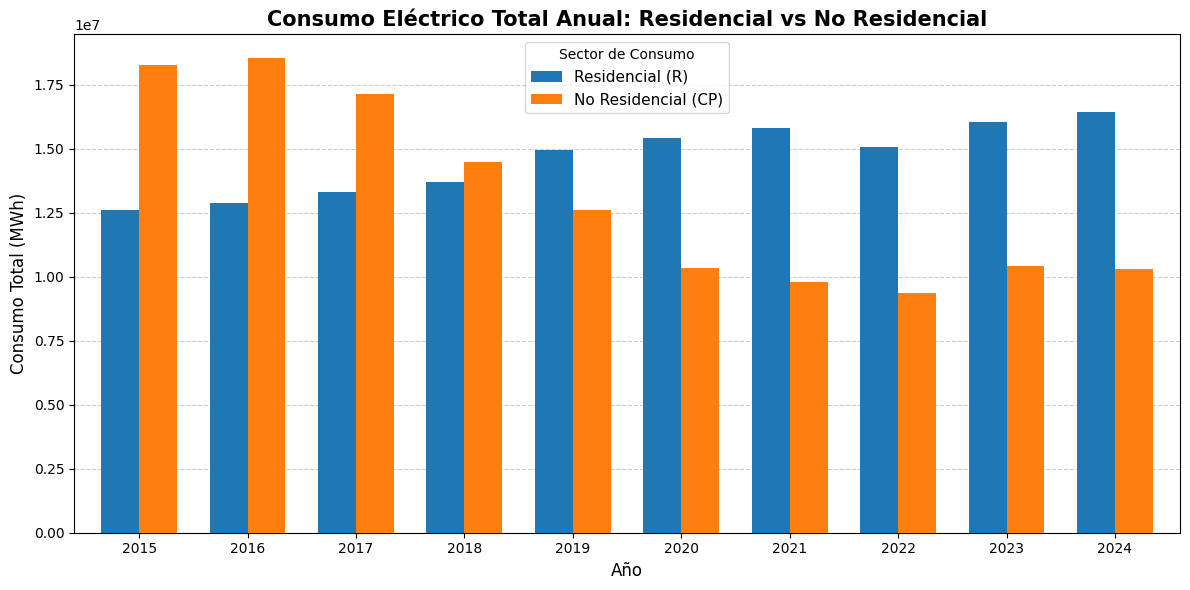

In [11]:
# 1. Extraer el año de la columna 'año_ms'
# Aseguramos que 'año_ms' sea datetime por si acaso
df_consumo_sectorial['año_ms'] = pd.to_datetime(df_consumo_sectorial['año_ms'])
df_consumo_sectorial['año'] = df_consumo_sectorial['año_ms'].dt.year

# 2. Agrupar por 'año' y sumar los consumos a nivel nacional
df_anual = df_consumo_sectorial.groupby('año')[['consumo_R_MWh', 'consumo_CP_MWh']].sum().reset_index()

# 3. Generar el gráfico de barras
# Seteamos el 'año' como índice para que Pandas lo use en el eje X automáticamente
df_plot = df_anual.set_index('año')

# Creamos la figura
ax = df_plot.plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.7, 
    color=['#1f77b4', '#ff7f0e'], # Azul para Residencial, Naranja para No Residencial
    zorder=10
)

# 4. Personalización del gráfico
plt.title('Consumo Eléctrico Total Anual: Residencial vs No Residencial', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Consumo Total (MWh)', fontsize=12)

# Modificar etiquetas de la leyenda para que sean más legibles
plt.legend(['Residencial (R)', 'No Residencial (CP)'], title='Sector de Consumo', fontsize=11)

# Mejorar la grilla y rotación de las fechas en el eje X
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Ajustar los márgenes para que no se corte nada
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [12]:
correcciones_sector = {
    # Palabras clave en la razón social : Sector Real (RCPIT)
    "CENCOSUD": "C",
    "WALMART": "C",
    "FALABELLA": "C",
    "MALL": "C",
    "SUPERMERCADO": "C",
    "SODIMAC": "C",
    "HOSPITAL": "P", # Público / Servicios
    "CLINICA": "P",
    "METRO": "T",    # Transporte
    "EFE": "T", 
    "UNIVERSIDAD": "P", 
    "SALUD": "P", 
    "INMOBILIARIA": "C"
}

In [13]:
df = df_clientes_libres.copy()

# 1. Transformación de Tipos de Datos y Fecha
df['Anio'] = pd.to_numeric(df['Anio'], errors='coerce')
df['NroMes'] = pd.to_numeric(df['NroMes'], errors='coerce')
df['RetiroEnergiaMWh'] = pd.to_numeric(df['RetiroEnergiaMWh'], errors='coerce')

# Limpiar nulos en fecha y crear columna datetime 'año_ms'
df = df.dropna(subset=['Anio', 'NroMes'])
df['año_ms'] = pd.to_datetime(
    df['Anio'].astype(int).astype(str) + '-' + 
    df['NroMes'].astype(int).astype(str).str.zfill(2) + '-01'
)

# 2. Estandarización de texto para búsqueda robusta
# Pasamos sectores a minúsculas y limpiamos espacios. La Razón Social a mayúsculas.
df['Sector_norm'] = df['SectorEconomico'].astype(str).str.lower().str.strip()
df['Subsector_norm'] = df['SubsectorEconomico'].astype(str).str.lower().str.strip()
df['Razon_norm'] = df['RazonSocialCliente'].astype(str).str.upper()

# 3. Clasificación Base inicial (mapeo general)
def mapeo_inicial(sector):
    if 'industrial' in sector or 'minero' in sector:
        return 'I'
    elif 'comercial' in sector:
        return 'C'
    elif 'público' in sector or 'publico' in sector or 'servicio' in sector:
        return 'P'
    elif 'transporte' in sector:
        return 'T'
    return 'Otros'

df['Sector_RCPIT'] = df['Sector_norm'].apply(mapeo_inicial)

# 4. APLICACIÓN DE REGLAS DE CORRECCIÓN (Sobrescribiendo la clasificación base)

# Regla A: Sector comercial + Subsector industrias varias -> Industrial
mask_a = (df['Sector_norm'] == 'comercial') & (df['Subsector_norm'] == 'industrias varias')
df.loc[mask_a, 'Sector_RCPIT'] = 'I'

# Regla B: Sector transporte + Subsector distinto a terrestre -> Comercial
mask_b = (df['Sector_norm'] == 'transporte') & (df['Subsector_norm'] != 'terrestre')
df.loc[mask_b, 'Sector_RCPIT'] = 'C'

# Regla C: Búsqueda de Palabras Clave en la Razón Social
diccionario_razon_social = {
    "CENCOSUD": "C", "WALMART": "C", "FALABELLA": "C", "MALL": "C",
    "SUPERMERCADO": "C", "SODIMAC": "C", "INMOBILIARIA": "C",
    "HOSPITAL": "P", "CLINICA": "P", "UNIVERSIDAD": "P", "SALUD": "P",
    "METRO": "T", "EFE": "T"
}

for palabra, sector_asignado in diccionario_razon_social.items():
    # Buscamos si la palabra clave está dentro de la Razón Social
    mask_c = df['Razon_norm'].str.contains(palabra, na=False)
    df.loc[mask_c, 'Sector_RCPIT'] = sector_asignado

# 5. Agrupación (Pivot Table) por Fecha, Región y Comuna
# Aquí se suman los consumos de distintas empresas que coinciden en comuna/mes y sector
df_agrupado = pd.pivot_table(
    df,
    values='RetiroEnergiaMWh',
    index=['año_ms', 'Region', 'Comuna'],
    columns='Sector_RCPIT',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 6. Asignar nombres finales solicitados a las columnas
# Usamos .get() por si acaso alguna categoría no resultó de la data (ej: no hay 'T')
df_agrupado['consumo_I_MWh'] = df_agrupado.get('I', 0)
df_agrupado['consumo_C_MWh'] = df_agrupado.get('C', 0)
df_agrupado['consumo_P_MWh'] = df_agrupado.get('P', 0)
df_agrupado['consumo_T_MWh'] = df_agrupado.get('T', 0)

# 7. Seleccionar columnas y limpiar nombres de ejes
columnas_finales = [
    'año_ms', 'Region', 'Comuna', 
    'consumo_I_MWh', 'consumo_C_MWh', 'consumo_P_MWh', 'consumo_T_MWh'
]
df_consumo_libres = df_agrupado[columnas_finales].copy()
df_consumo_libres.columns.name = None

# Mostrar resultados
print(df_consumo_libres.head())

      año_ms       Region                Comuna  consumo_I_MWh  consumo_C_MWh  \
0 2000-01-01  ANTOFAGASTA           ANTOFAGASTA       214796.9            0.0   
1 2000-01-01  ANTOFAGASTA                CALAMA       240286.5            0.0   
2 2000-01-01  ANTOFAGASTA            MEJILLONES        16892.6            0.0   
3 2000-01-01  ANTOFAGASTA  SAN PEDRO DE ATACAMA         9280.2            0.0   
4 2000-01-01  ANTOFAGASTA          SIERRA GORDA        11293.6            0.0   

   consumo_P_MWh  consumo_T_MWh  
0            0.0            0.0  
1            0.0            0.0  
2            0.0            0.0  
3            0.0            0.0  
4            0.0            0.0  


In [14]:
# 0. Estandarizar nombres de las columnas clave (Region y Comuna)
df_consumo_libres = df_consumo_libres.rename(columns={'Region': 'region', 'Comuna': 'comuna'})

# Definir el parámetro arbitrario alpha (ejemplo: 30% Público, 70% Comercial)
alpha = 0.50

# =========================================================
# DF2: DATOS DE CONSUMO - CLIENTES REGULADOS
# =========================================================
df2 = df_consumo_sectorial.copy()

# 1. Desagregar el bloque CP usando alpha
df2['consumo_P_MWh'] = df2['consumo_CP_MWh'] * alpha
df2['consumo_C_MWh'] = df2['consumo_CP_MWh'] * (1 - alpha)

# 2. Eliminar la columna agregada original
df2 = df2.drop(columns=['consumo_CP_MWh'])

# 3. Asignar 0 a los sectores sin participación regulada en la base
df2['consumo_I_MWh'] = 0.0
df2['consumo_T_MWh'] = 0.0

# =========================================================
# DF3: DATOS DE CONSUMO - CLIENTES LIBRES
# =========================================================
df3 = df_consumo_libres.copy()

# 1. Asignar 0 al sector Residencial (no existe mercado libre residencial)
df3['consumo_R_MWh'] = 0.0

# Aseguramos que df2 y df3 tengan exactamente las mismas columnas y orden
columnas_estandar = ['año_ms', 'region', 'comuna', 'consumo_R_MWh', 'consumo_C_MWh', 'consumo_P_MWh', 'consumo_I_MWh', 'consumo_T_MWh']
df2 = df2[columnas_estandar]
df3 = df3[columnas_estandar]

# =========================================================
# DF1: BALANCE COMUNAL TOTAL (Libres + Regulados)
# =========================================================
# Concatenamos ambas bases una debajo de otra
df_concat = pd.concat([df2, df3], ignore_index=True)

# Agrupamos por mes, región y comuna, y sumamos. 
# Si en una comuna/mes hay consumo regulado y libre en un mismo sector, se sumarán.
df1 = df_concat.groupby(['año_ms', 'region', 'comuna'], as_index=False).sum()

# Mostrar resultados
print("=== DF1: Balance Total Comunal (Head) ===")
print(df1.head())

=== DF1: Balance Total Comunal (Head) ===
      año_ms       region                comuna  consumo_R_MWh  consumo_C_MWh  \
0 2000-01-01  ANTOFAGASTA           ANTOFAGASTA            0.0            0.0   
1 2000-01-01  ANTOFAGASTA                CALAMA            0.0            0.0   
2 2000-01-01  ANTOFAGASTA            MEJILLONES            0.0            0.0   
3 2000-01-01  ANTOFAGASTA  SAN PEDRO DE ATACAMA            0.0            0.0   
4 2000-01-01  ANTOFAGASTA          SIERRA GORDA            0.0            0.0   

   consumo_P_MWh  consumo_I_MWh  consumo_T_MWh  
0            0.0       214796.9            0.0  
1            0.0       240286.5            0.0  
2            0.0        16892.6            0.0  
3            0.0         9280.2            0.0  
4            0.0        11293.6            0.0  


In [15]:
# Filtrar datos 
filtered_df1 = df1.loc[(df1['año_ms'].dt.year >= 2018) & 
                       (df1['año_ms'].dt.year < 2022)]

filtered_df2 = df2.loc[(df2['año_ms'].dt.year >= 2018) & 
                       (df2['año_ms'].dt.year < 2022)]

filtered_df3 = df3.loc[(df3['año_ms'].dt.year >= 2018) & 
                       (df3['año_ms'].dt.year < 2022)]

In [16]:
# Cargar datos de consumos comunales
df_comunal_horaria = pd.read_csv("../data/raw/demanda_comunal_horaria.csv")

Parámetros calculados (Head):
    año           comuna  mu_comuna  sigma_comuna
0  2018        ALGARROBO   3.341352      0.829690
1  2018            ALHUÉ   0.881714      1.786091
2  2018  ALTO DEL CARMEN   1.736457      0.707980
3  2018    ALTO HOSPICIO   4.941135      6.256497
4  2018            ANCUD   7.080370      1.785093

Coeficiente de Correlación de Pearson (mu vs sigma): 0.8324


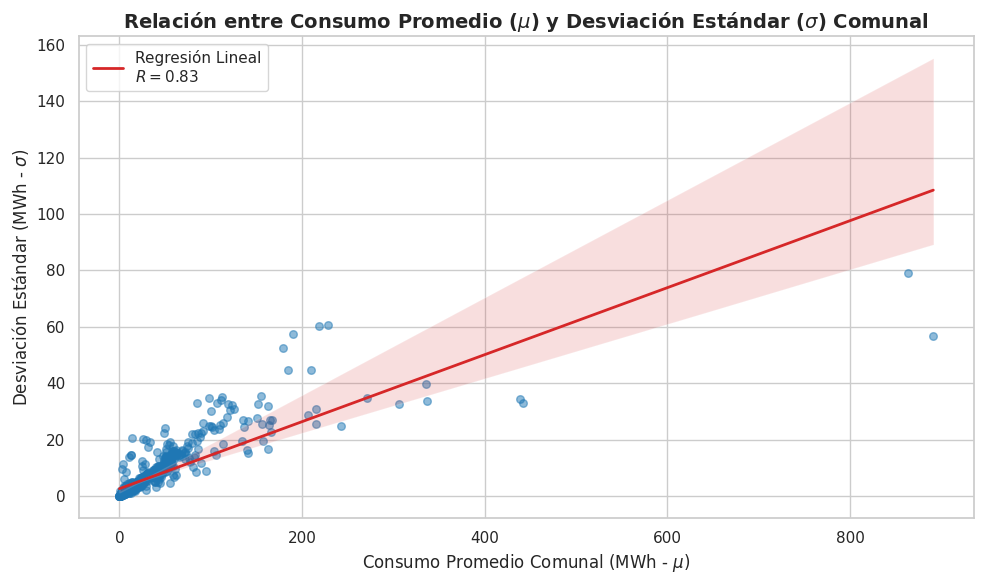

In [17]:
df = df_comunal_horaria.copy()

# 1. Asegurar formato datetime y extraer el año
df['valid_time'] = pd.to_datetime(df['valid_time'], errors='coerce')
df['año'] = df['valid_time'].dt.year

# (Opcional) Si aún no has filtrado la base entre 2018 y 2021 en este dataframe:
df = df[df['año'].between(2018, 2021)]

# 2. Estandarizar el nombre de las comunas (Mayúsculas y sin espacios extra)
# Nota: Si tienes problemas con tildes (ej. ÁLAMOS vs ALAMOS), puedes agregar 
# .str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
df['comuna'] = df['comuna'].astype(str).str.upper().str.strip()

# 3. Agrupar por año y comuna, calculando Promedio (mu) y Desviación Estándar (sigma)
# Se agrupa por año y comuna para tener los parámetros específicos de estandarización
df_stats = df.groupby(['año', 'comuna'])['demanda_mwh'].agg(
    mu_comuna='mean',
    sigma_comuna='std'
).reset_index()

# Filtrar posibles NaN en sigma (ocurriría si alguna comuna tuviera solo 1 registro en todo el año)
df_stats = df_stats.dropna(subset=['mu_comuna', 'sigma_comuna'])

# Mostrar los primeros registros de los parámetros calculados
print("Parámetros calculados (Head):")
print(df_stats.head())

# ==========================================
# 4. ANÁLISIS DE CORRELACIÓN Y GRÁFICO
# ==========================================

# Calcular el coeficiente de correlación de Pearson
correlacion = df_stats['mu_comuna'].corr(df_stats['sigma_comuna'])
print(f"\nCoeficiente de Correlación de Pearson (mu vs sigma): {correlacion:.4f}")

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear un gráfico de dispersión con línea de regresión (regplot)
ax = sns.regplot(
    data=df_stats, 
    x='mu_comuna', 
    y='sigma_comuna',
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4', 's': 30}, # Transparencia para ver densidad
    line_kws={'color': '#d62728', 'linewidth': 2, 'label': f'Regresión Lineal\n$R = {correlacion:.2f}$'}
)

# Personalización del gráfico
plt.title('Relación entre Consumo Promedio ($\mu$) y Desviación Estándar ($\sigma$) Comunal', 
          fontsize=14, fontweight='bold')
plt.xlabel('Consumo Promedio Comunal (MWh - $\mu$)', fontsize=12)
plt.ylabel('Desviación Estándar (MWh - $\sigma$)', fontsize=12)
plt.legend()
plt.tight_layout()

# Mostrar el gráfico
plt.show()

--- Parámetros de la Ley de Potencias ---
Pendiente (m): 0.8988
Intercepto (n): -1.1315
Fórmula Resultante: sigma = exp(-1.1315) * mu^0.8988
Correlación (R2): 0.9271
-----------------------------------------


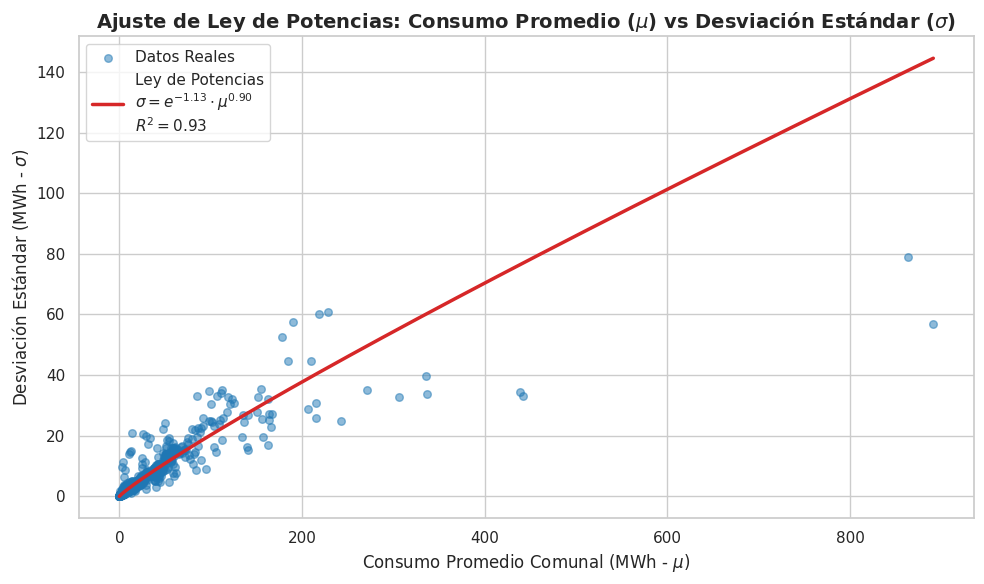

In [18]:
# 1. Aseguramos que tenemos los logaritmos calculados
df_stats['log_sigma'] = np.log(df_stats['sigma_comuna'])
df_stats['log_mu'] = np.log(df_stats['mu_comuna'])

# 2. Extraer los parámetros 'm' (pendiente) y 'n' (intercepto) usando linregress
# Esto ajusta la recta: log_sigma = m * log_mu + n
slope, intercept, r_value, p_value, std_err = linregress(df_stats['log_mu'], df_stats['log_sigma'])

m = slope
n = intercept
r_potencia = r_value

print(f"--- Parámetros de la Ley de Potencias ---")
print(f"Pendiente (m): {m:.4f}")
print(f"Intercepto (n): {n:.4f}")
print(f"Fórmula Resultante: sigma = exp({n:.4f}) * mu^{m:.4f}")
print(f"Correlación (R2): {r_potencia**2:.4f}")
print(f"-----------------------------------------")

# ==========================================
# 3. GRAFICAR EN ESCALA ORIGINAL (mu vs sigma)
# ==========================================

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# A. Graficar los datos reales (Puntos)
plt.scatter(
    df_stats['mu_comuna'], 
    df_stats['sigma_comuna'],
    alpha=0.5, 
    color='#1f77b4', 
    s=30, 
    label='Datos Reales'
)

# B. Construir y graficar la curva teórica (Ley de Potencias)
# Generamos un vector de X (mu) continuo desde el valor mínimo al máximo
mu_range = np.linspace(df_stats['mu_comuna'].min(), df_stats['mu_comuna'].max(), 500)

# Aplicamos la fórmula: sigma = exp(n) * mu^m
sigma_pred = np.exp(n) * (mu_range ** m)

# Trazamos la línea
plt.plot(
    mu_range, 
    sigma_pred, 
    color='#d62728', 
    linewidth=2.5, 
    label=f'Ley de Potencias\n$\sigma = e^{{{n:.2f}}} \cdot \mu^{{{m:.2f}}}$\n$R^2 = {r_potencia**2:.2f}$'
)

# Personalización del gráfico
plt.title('Ajuste de Ley de Potencias: Consumo Promedio ($\mu$) vs Desviación Estándar ($\sigma$)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Consumo Promedio Comunal (MWh - $\mu$)', fontsize=12)
plt.ylabel('Desviación Estándar (MWh - $\sigma$)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [19]:
# 1. Calcular Consumo Total Mensual
# Sumamos horizontalmente (axis=1) todas las columnas sectoriales
columnas_sectores = ['consumo_R_MWh', 'consumo_C_MWh', 'consumo_P_MWh', 'consumo_I_MWh', 'consumo_T_MWh']
filtered_df1['consumo_total_mes_MWh'] = filtered_df1[columnas_sectores].sum(axis=1)

# 2. Crear DataFrame de Consumo Total Anual
# Extraemos el año de la columna datetime y agrupamos
filtered_df1['año'] = filtered_df1['año_ms'].dt.year

df_total_anual = filtered_df1.groupby(['año', 'region', 'comuna'], as_index=False)['consumo_total_mes_MWh'].sum()
df_total_anual.rename(columns={'consumo_total_mes_MWh': 'consumo_total_anual_MWh'}, inplace=True)

print("Muestra del DataFrame Anual:")
print(df_total_anual.head())

Muestra del DataFrame Anual:
    año       region                comuna  consumo_total_anual_MWh
0  2018  ANTOFAGASTA           ANTOFAGASTA              6840534.599
1  2018  ANTOFAGASTA                CALAMA              3652229.405
2  2018  ANTOFAGASTA           MARÍA ELENA                41511.500
3  2018  ANTOFAGASTA            MEJILLONES              1570115.104
4  2018  ANTOFAGASTA  SAN PEDRO DE ATACAMA               484957.100


In [20]:
# ==========================================
# A. NORMALIZACIÓN BÁSICA (Quitar tildes y espacios)
# ==========================================
def limpiar_comuna(serie):
    return serie.astype(str).str.upper().str.strip() \
                .str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Aplicamos la limpieza a ambas bases
filtered_df1['comuna_norm'] = limpiar_comuna(filtered_df1['comuna'])
df_comunal_horaria['comuna_norm'] = limpiar_comuna(df_comunal_horaria['comuna'])

# ==========================================
# B. FUZZY MATCHING
# ==========================================
# Obtenemos la lista única de comunas de la base del CEN (nuestro "Diccionario Oficial")
comunas_cen = df_comunal_horaria['comuna_norm'].dropna().unique()

def buscar_mejor_match(comuna_buscada, opciones, umbral=95):
    """
    Busca la comuna más parecida. Devuelve el nombre si el parecido 
    supera el umbral (0 a 100), sino devuelve None.
    """
    # extractOne devuelve una tupla: (Mejor_Match, Puntaje_Similitud)
    mejor_match, puntaje = process.extractOne(comuna_buscada, opciones, scorer=fuzz.token_sort_ratio)
    
    if puntaje >= umbral:
        return mejor_match
    else:
        # Imprime los casos problemáticos para que los revises manualmente
        print(f"Alerta: '{comuna_buscada}' no superó el umbral. Mejor coincidencia: '{mejor_match}' ({puntaje}%)")
        return None

# OPTIMIZACIÓN: En vez de aplicarlo a cientos de miles de filas, lo aplicamos solo a las comunas únicas
mapa_comunas = pd.DataFrame({'comuna_norm': filtered_df1['comuna_norm'].unique()})

# Buscamos el equivalente en el CEN para cada comuna de nuestro df1
mapa_comunas['comuna_match_cen'] = mapa_comunas['comuna_norm'].apply(
    lambda x: buscar_mejor_match(x, comunas_cen)
)

# Cruzamos nuestro mapa de vuelta a la base de datos completa
filtered_df1 = filtered_df1.merge(mapa_comunas, on='comuna_norm', how='left')

# ==========================================
# C. CRUCE FINAL CON CEN
# ==========================================
# Ahora puedes hacer merge tranquilamente usando 'comuna_match_cen' de df1 
# contra 'comuna_norm' de df_comunal_horaria

Alerta: 'CAMINA' no superó el umbral. Mejor coincidencia: 'CALAMA' (67%)
Alerta: 'AISEN' no superó el umbral. Mejor coincidencia: 'TRAIGUEN' (62%)
Alerta: 'CHILE CHICO' no superó el umbral. Mejor coincidencia: 'CHONCHI' (67%)
Alerta: 'CISNES' no superó el umbral. Mejor coincidencia: 'LINARES' (62%)
Alerta: 'COCHRANE' no superó el umbral. Mejor coincidencia: 'CORONEL' (67%)
Alerta: 'COIHAIQUE' no superó el umbral. Mejor coincidencia: 'DONIHUE' (62%)
Alerta: 'LAGO VERDE' no superó el umbral. Mejor coincidencia: 'LA SERENA' (63%)
Alerta: 'RIO IBANEZ' no superó el umbral. Mejor coincidencia: 'RIO BUENO' (63%)
Alerta: 'ANTUCO' no superó el umbral. Mejor coincidencia: 'ARAUCO' (67%)
Alerta: 'COELEMU' no superó el umbral. Mejor coincidencia: 'CATEMU' (62%)
Alerta: 'CONTULMO' no superó el umbral. Mejor coincidencia: 'COLTAUCO' (62%)
Alerta: 'FLORIDA' no superó el umbral. Mejor coincidencia: 'LA FLORIDA' (82%)
Alerta: 'HUALQUI' no superó el umbral. Mejor coincidencia: 'PUNITAQUI' (62%)
Alerta: 

In [21]:
# =========================================================
# 1. TOTALES ANUALES: BASE CALCULADA (filtered_df1)
# =========================================================
# Aseguramos de tener el año (si no lo creaste antes)
if 'año' not in filtered_df1.columns:
    filtered_df1['año'] = filtered_df1['año_ms'].dt.year

# Agrupamos por año y por el nombre de la comuna que hizo match con el CEN
df_calc = filtered_df1.dropna(subset=['comuna_match_cen']).groupby(
    ['año', 'comuna_match_cen'], as_index=False
)['consumo_total_mes_MWh'].sum()

# Renombramos para estandarizar de cara al cruce
df_calc.rename(columns={
    'comuna_match_cen': 'comuna',
    'consumo_total_mes_MWh': 'calc'
}, inplace=True)


# =========================================================
# 2. TOTALES ANUALES: BASE CEN (df_comunal_horaria)
# =========================================================
# Aseguramos de tener el año extraído de la fecha
if 'año' not in df_comunal_horaria.columns:
    df_comunal_horaria["valid_time"] = pd.to_datetime(df_comunal_horaria["valid_time"])
    # Cambia 'fecha_hora' por el nombre real de tu columna de tiempo si es distinto
    df_comunal_horaria['año'] = df_comunal_horaria['valid_time'].dt.year 

# Agrupamos por año y comuna normalizada. 
# NOTA: Cambia 'demanda_mwh' por el nombre real de tu columna de consumo en la base del CEN
df_cen = df_comunal_horaria.groupby(
    ['año', 'comuna_norm'], as_index=False
)['demanda_mwh'].sum()

# Renombramos para estandarizar
df_cen.rename(columns={
    'comuna_norm': 'comuna',
    'demanda_mwh': 'cen'
}, inplace=True)


# =========================================================
# 3. MERGE Y COMPARACIÓN
# =========================================================
# Usamos un 'outer' merge. Esto es útil porque si una comuna está en df_calc 
# pero falta en df_cen (o viceversa), no desaparecerá, sino que mostrará un NaN.
df_comparacion = pd.merge(
    df_calc, 
    df_cen, 
    on=['año', 'comuna'], 
    how='outer'
)

# BONUS: Calcular la diferencia y el error porcentual para evaluar la brecha
df_comparacion['diferencia_MWh'] = df_comparacion['calc'] - df_comparacion['cen']
df_comparacion['error_porcentual_%'] = (abs(df_comparacion['diferencia_MWh']) / df_comparacion['cen']) * 100

# Ordenamos para verlo más claro
df_comparacion = df_comparacion.sort_values(by=['año', 'error_porcentual_%'], ascending=[True, False]).reset_index(drop=True)

print("Muestra del DataFrame Comparativo:")
print(df_comparacion.head())

Muestra del DataFrame Comparativo:
    año           comuna         calc           cen  diferencia_MWh  \
0  2018        SALAMANCA  1309744.542  16248.151052    1.293496e+06   
1  2018        ANDACOLLO   497410.449   6171.245090    4.912392e+05   
2  2018       MEJILLONES  1570115.104  20683.074280    1.549432e+06   
3  2018            HUARA     7907.525    109.770583    7.797754e+03   
4  2018  TIERRA AMARILLA  2325124.244  36769.443286    2.288355e+06   

   error_porcentual_%  
0         7960.883591  
1         7960.131169  
2         7491.304284  
3         7103.683160  
4         6223.523111  


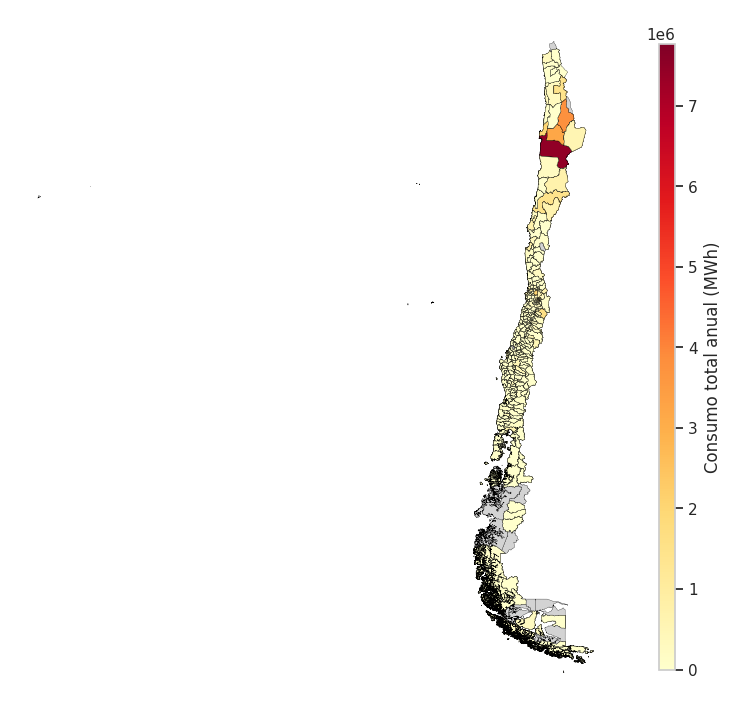

In [22]:
# 1. Cargar la capa geográfica de las comunas (que ya usaste antes en MERLIN)
gdf_comunas = gpd.read_file("../data/raw/capa_comunal.gpkg")

# 2. Unir (Merge) la geografía con tus resultados
# Asume que df_metricas_comunales tiene una columna 'comuna' con el nombre exacto o un código ID
gdf_mapa = gdf_comunas.merge(df_total_anual, on="comuna", how="left")

# 3. Configurar la figura (Chile es largo, por lo que la figura debe ser alta)
fig, ax = plt.subplots(1, 1, figsize=(8, 16))

# 4. Graficar la geocapa (Choropleth)
gdf_mapa.plot(
    column="consumo_total_anual_MWh",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={
        "label": "Consumo total anual (MWh)",
        "shrink": 0.4,  # Disminuye o aumenta la altura de la barra (ej: 0.5 a 0.8)
        "aspect": 40,  # Controla el grosor de la barra (mayor número = más delgada)
        "pad": 0.05,  # Controla la separación entre el mapa y la barra
        "orientation": "vertical",
    },
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
    edgecolor="black",
    linewidth=0.2,
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

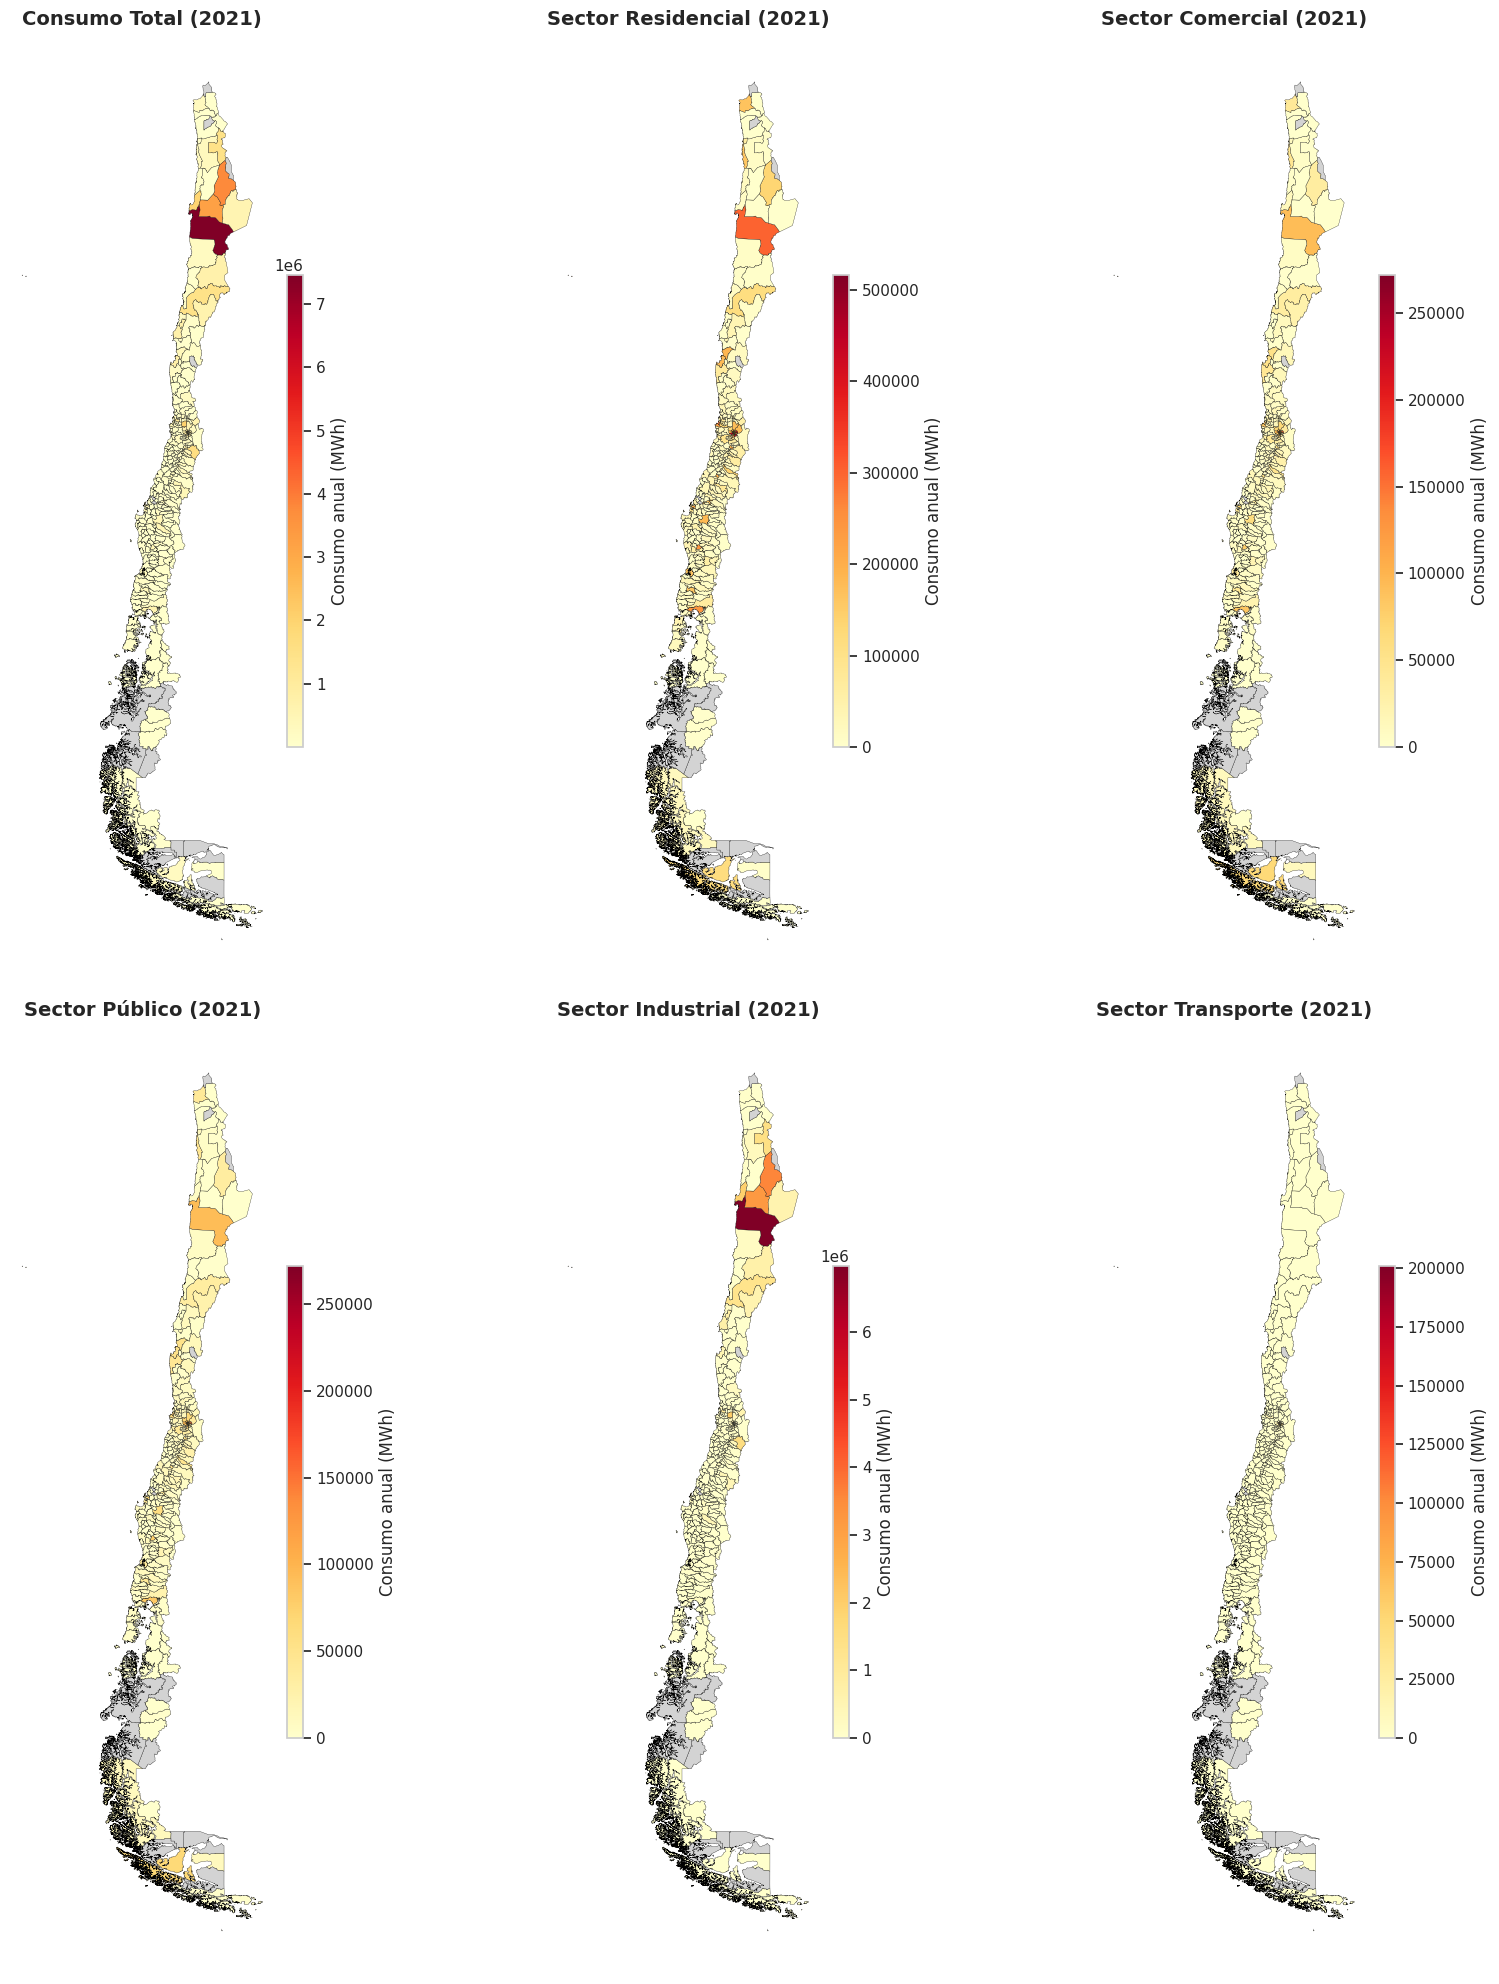

In [23]:
# =========================================================
# 1. PREPARACIÓN DE DATOS: TOTALES ANUALES 2021 POR SECTOR
# =========================================================
# Asumiendo que partes de tu base desagregada (ej. df_resultados_des)
# Paso 1: Filtrar solo el año 2021
df_2021 = filtered_df1[filtered_df1['año'] == 2021].copy()

# Paso 2: Definir las columnas de interés (Ajusta estos nombres si son diferentes en tu base)
columnas_sectores = [
    'consumo_total_mes_MWh', # Tu total
    'consumo_R_MWh', 
    'consumo_C_MWh', 
    'consumo_P_MWh', 
    'consumo_I_MWh', 
    'consumo_T_MWh'
]

# Paso 3: Agrupar por comuna y sumar todo el año
df_total_anual = df_2021.groupby('comuna')[columnas_sectores].sum().reset_index()

# (Opcional) Renombrar para facilitar la llamada en el ploteo
df_total_anual.columns = ['comuna', 'Total', 'Residencial', 'Comercial', 'Público', 'Industrial', 'Transporte']

# =========================================================
# 2. MERGE CON CAPA GEOGRÁFICA
# =========================================================
gdf_comunas = gpd.read_file("../data/raw/capa_comunal.gpkg")
gdf_mapa = gdf_comunas.merge(df_total_anual, on="comuna", how="left")

# =========================================================
# 3. ELIMINAR CHILE INSULAR Y ANTÁRTICO
# =========================================================
# La forma más robusta en GeoPandas es recortar por Bounding Box (cx).
# Chile continental está al Este de la longitud -76° y al Norte de la latitud -56°.
# Esto elimina automáticamente a Isla de Pascua (-109°), Juan Fernández (-79°) y Antártica,
# pero mantiene perfectamente a Chiloé y Magallanes.
gdf_mapa = gdf_mapa.cx[-76:, -56:] 

# (Alternativa si prefieres hacerlo por nombre):
# gdf_mapa = gdf_mapa[~gdf_mapa['comuna'].isin(['ISLA DE PASCUA', 'JUAN FERNANDEZ', 'ANTARTICA'])]

# =========================================================
# 4. CONFIGURACIÓN DE LA FIGURA (6 MAPAS)
# =========================================================
# Creamos una cuadrícula de 2 filas y 3 columnas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Aplana la matriz a una lista de 6 "ax" para iterar fácilmente

# Variables para el bucle
sectores_a_graficar = ['Total', 'Residencial', 'Comercial', 'Público', 'Industrial', 'Transporte']
titulos = [
    'Consumo Total (2021)', 
    'Sector Residencial (2021)', 
    'Sector Comercial (2021)', 
    'Sector Público (2021)', 
    'Sector Industrial (2021)', 
    'Sector Transporte (2021)'
]

# =========================================================
# 5. BUCLE DE GRAFICACIÓN CHOROPLETH
# =========================================================
for ax, sector, titulo in zip(axes, sectores_a_graficar, titulos):
    gdf_mapa.plot(
        column=sector,
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        legend_kwds={
            "label": "Consumo anual (MWh)",
            "shrink": 0.5,  # Ajustado para que quepa bien en el subplot
            "aspect": 30,   
            "pad": 0.02,    
            "orientation": "vertical",
        },
        missing_kwds={"color": "lightgrey", "label": "Sin datos"},
        edgecolor="black",
        linewidth=0.2,
    )
    
    # Estética de cada subplot
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    ax.set_axis_off() # Apaga las coordenadas numéricas para un look más limpio

# Ajustar los espacios entre mapas y mostrar
plt.tight_layout()
plt.show()

In [28]:
# Guardar los shares comunal en versión final y que coincidan con las comunas del CEN 
df_shares_comunal = filtered_df1.copy()
df_shares_comunal = df_shares_comunal.drop(columns=["comuna", "comuna_norm"])
df_shares_comunal = df_shares_comunal.dropna(subset="comuna_match_cen")
df_shares_comunal.rename(columns={"comuna_match_cen": "comuna"}, inplace=True)
# Corregir valores negativos
sectores = ["R", "C", "P", "I", "T"]
lista_consumos = []
for i in sectores: 
    col = f"consumo_{i}_MWh"
    df_shares_comunal[col] = abs(df_shares_comunal[col])
    lista_consumos.append(col)

df_shares_comunal["consumo_total_mes_MWh"] = df_shares_comunal[lista_consumos].sum(axis=1)
df_shares_comunal.to_parquet("../data/interim/shares_comunales.parquet", index=False, engine="pyarrow")